# Text generation

In [4]:
import numpy as np
from tensorflow import keras
import sentencepiece as spm

2026-04-21 08:19:45.284496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776748785.314331     597 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776748785.326186     597 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776748785.448235     597 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776748785.448320     597 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776748785.448322     597 computation_placer.cc:177] computation placer alr

In [36]:
# read file and remove empty lines
with open('./sonnets.txt', 'r', encoding='utf-8-sig') as file:
    raw = file.read()

# split into separate poems and remove titles
poems = [p for p in raw.split('\n\n') if len(p.strip()) >= 10]
# clean lines
poems = [p.strip() for p in poems if p.strip()]
# add special tokens to start/end of each sonnet
poems = [f"<SONNET>\n{p}\n</SONNET>" for p in poems]
#poems = [p.replace('\\n', '\n') for p in poems]
#print(poems)
#print(raw)
print(poems[0])
print(f"Text length: {len(poems)} characters")
#print(f"First 100 characters: {text[:100]}")

<SONNET>
From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou, contracted to thine own bright eyes,
Feed’st thy light’s flame with self-substantial fuel,
Making a famine where abundance lies,
Thyself thy foe, to thy sweet self too cruel:
Thou that art now the world’s fresh ornament,
And only herald to the gaudy spring,
Within thine own bud buriest thy content,
And tender churl mak’st waste in niggarding:
    Pity the world, or else this glutton be,
    To eat the world’s due, by the grave and thee.
</SONNET>
Text length: 154 characters


In [79]:
tmp = 'sonnets_tmp.txt'
with open(tmp, 'w', encoding='utf-8') as f:
    f.write('\n'.join(poems))

vocab_size = 2000
model_prefix ='input'

spm.SentencePieceTrainer.train(
    input=tmp,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<SONNET>', '</SONNET>'])
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

test_text = "It was upon"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁It', '▁was', '▁upon']
Vocabulary size: 2000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: sonnets_tmp.txt
  input_format: 
  model_prefix: input
  model_type: BPE
  vocab_size: 2000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <PAD>
  user_defined_symbols: <SONNET>
  user_defined_symbols: </SONNET>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_pi

In [80]:
seq_length = 192
pad_id = sp.piece_to_id("<PAD>")
def pad_or_truncate(seq, max_len):
    if len(seq) > max_len:
        return seq[:max_len]
    return seq + [pad_id] * (max_len - len(seq))  # assuming 0 = PAD

In [81]:
print(inputs)

<KerasTensor shape=(None, 192), dtype=float32, sparse=False, ragged=False, name=keras_tensor_208>


In [82]:

encoded_poems = [sp.encode_as_ids(p) for p in poems]
print(f"Total tokens: {len(pieces)}")

sequences = [pad_or_truncate(p, seq_length + 1) for p in encoded_poems]
sequences = np.array(sequences)


inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 138081
Number of sequences: 154
Input shape: (154, 192)
Target shape: (154, 192)


In [91]:
# Cell 5: Define the model
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

# Define model parameters
embed_dim = 192
num_heads = 4
ff_dim = 384
num_layers = 2

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)




import tensorflow as tf

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction='none'
)

def masked_loss(y_true, y_pred):
    # compute per-token loss
    loss = loss_fn(y_true, y_pred)

    # mask: 1 where NOT PAD, 0 where PAD
    mask = tf.cast(tf.not_equal(y_true, pad_id), tf.float32)

    # apply mask
    loss = loss * mask

    # average only over real tokens
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


def masked_accuracy(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)

    matches = tf.cast(tf.equal(y_true, y_pred), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, pad_id), tf.float32)

    return tf.reduce_sum(matches * mask) / tf.reduce_sum(mask)



# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=masked_loss,
    metrics=[masked_accuracy]
)

model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33      │ (None, 192)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 192, 192)  │    384,000 │ input_layer_33[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_55 (Add)        │ (None, 192, 192)  │          0 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 192, 192)  │    148,224 │ add_55[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_55[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_56 (Add)        │ (None, 192, 192)  │          0 │ add_55[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 192, 192)  │        384 │ add_56[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_22       │ (None, 192, 192)  │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_57 (Add)        │ (None, 192, 192)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_22[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 192, 192)  │        384 │ add_57[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 192, 192)  │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_58 (Add)        │ (None, 192, 192)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 192, 192)  │        384 │ add_58[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_23       │ (None, 192, 192)  │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_59 (Add)        │ (None, 192, 192)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 192, 192)  │        384 │ add_59[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 192, 2000) │    386,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,364,048 (5.20 MB)

 Trainable params: 1,364,048 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
batch_size = 8
epochs = 100

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('sonnets.keras', save_best_only=True)
    ]
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 4.1954 - masked_accuracy: 0.2289 - val_loss: 5.8471 - val_masked_accuracy: 0.1130 - learning_rate: 1.6653e-20
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.1986 - masked_accuracy: 0.2285 - val_loss: 5.8471 - val_masked_accuracy: 0.1130 - learning_rate: 1.6653e-20
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.1979 - masked_accuracy: 0.2273 - val_loss: 5.8471 - val_masked_accuracy: 0.1130 - learning_rate: 8.3267e-21
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.1969 - masked_accuracy: 0.2264 - val_loss: 5.8471 - val_masked_accuracy: 0.1130 - learning_rate: 4.1633e-21
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.1958 - masked_accuracy: 0.2297 - val_loss: 5.8471 - val_masked_accuracy: 0.1130 - learning_rate: 2.0817e-21
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.1972 - masked_accuracy: 0.2268 - val_loss: 5.8471 - val_masked_accuracy: 0.1130 - learni

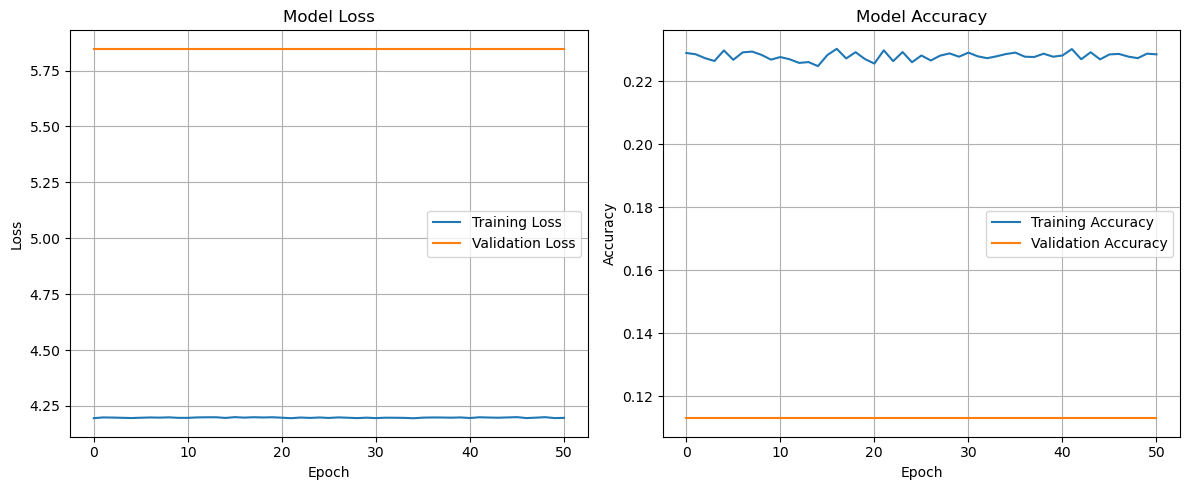

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['masked_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_masked_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
model.save('kalevala_model.keras')

In [95]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [96]:
# Cell 10: Generate sample text
prompts = [
    "yes",
    "<SONNET>"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.0)
    print(generated)


Prompt: yes
yes<PAD> becomings bad Both thanank myself grief withstantisonce Allbt. </SONNET>eep. </SONNET>ilding kiss. </SONNET> colour or farther. </SONNET> me Let wrong bitter</SONNET> affander foul youngings have meetselvesxwhere seeing colourtis these let</SONNET> answer not we meet </SONNET>igh myides look proc purehed bl</SONNET> winter Have </SONNET> tongue gracious whether gaz sheght L reftis summer audit beauty tombok colour.rown Was. </SONNET> spent. </SONNET>.

Prompt: <SONNET>
<SONNET> This</SONNET>gle my young</SONNET> seal beg pat bount wasple art hate flesh seen, Ah bears like speak. </SONNET> summeriv servy HerWhysicstant roboigh. </SONNET> ragethriieve none colour seem</SONNET> that heartingost prove Soeeds mine side pleasure. </SONNET>. </SONNET>eastf action Why crime amiss tw worth </SONNET>  mak belising when hast on seem more pure un</SONNET> sw sadeak Diedigur help uad. And or feassal yetides play
